In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
btc = pd.read_csv("coin_Bitcoin.csv")
btc = btc.drop(['SNo', 'Name', 'Volume', 'Marketcap', 'High', 'Low', 'Open'], axis=1) 

btc_train = btc.iloc[2700:2800]

btc_train.head()

,Symbol,Date,Close
2700,BTC,2020-09-19 23:59:59,11094.346276
2701,BTC,2020-09-20 23:59:59,10938.271289
2702,BTC,2020-09-21 23:59:59,10462.259619
2703,BTC,2020-09-22 23:59:59,10538.460321
2704,BTC,2020-09-23 23:59:59,10246.186493


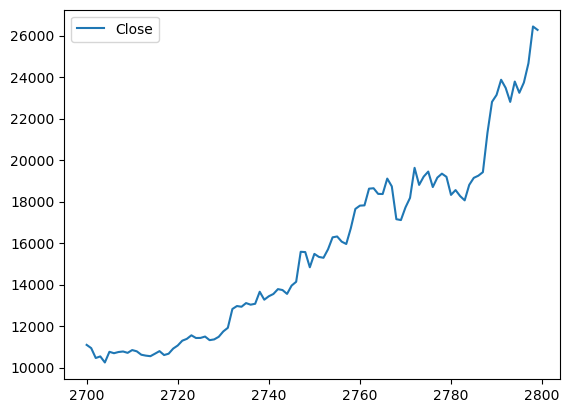

In [3]:
btc_train.plot()
plt.show()

In [4]:
from statsmodels.tsa.stattools import adfuller

In [5]:
result = adfuller(btc_train['Close'])

print('p-value:', result[1])     

if result[1] <= 0.05:
    print("Ряд стационарен")
else:
    print("Ряд не стационарен")

p-value: 0.9973373677685241
Ряд не стационарен


In [6]:
from scipy.stats import boxcox

transformed_data, lambda_opt = boxcox(btc_train['Close'])
btc_train['Close_transformed'] = transformed_data
print(f"Оптимальный λ: {lambda_opt:.3f}")

Оптимальный λ: -0.427


/var/folders/_v/q0x0ct1d7vsccvqk4j4jzkzw0000gn/T/ipykernel_83991/1940964668.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_train['Close_transformed'] = transformed_data


In [7]:
result = adfuller(btc_train['Close_transformed'])

print('p-value:', result[1])     

if result[1] <= 0.05:
    print("Ряд стационарен")
else:
    print("Ряд не стационарен")

p-value: 0.9862796268867069
Ряд не стационарен


In [8]:
Close_diff = btc_train['Close'].diff()
btc_train['Close_diff'] = Close_diff
btc_train = btc_train.iloc[1:]

/var/folders/_v/q0x0ct1d7vsccvqk4j4jzkzw0000gn/T/ipykernel_83991/1576772875.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_train['Close_diff'] = Close_diff


In [9]:
result = adfuller(btc_train['Close_diff'])

print('p-value:', result[1])     

if result[1] <= 0.05:
    print("Ряд стационарен")
else:
    print("Ряд не стационарен")

p-value: 3.654658422908584e-15
Ряд стационарен


In [10]:
from pmdarima import auto_arima

model = auto_arima(
    btc_train['Close'],
    d = 1,
    seasonal=False,
    stepwise=False,
    trace=True,
    boxcox=-0.427
)

 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1513.344, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1515.328, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1516.555, Time=0.02 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1518.422, Time=0.04 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=1520.088, Time=0.06 sec
 ARIMA(0,1,5)(0,0,0)[0] intercept   : AIC=1521.854, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1515.335, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1517.287, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1518.422, Time=0.05 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1520.416, Time=0.08 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=1522.175, Time=0.11 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1516.518, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1518.520, Time=0.01 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1520.261, Time=0.06 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=1522.133, Time=0.08 sec
 ARIMA(3,1

In [11]:
forecast, conf_int = model.predict(nriods=10, return_conf_int=True)

In [12]:
btc_test = btc.iloc[2700:2810]

forecast_dates = np.arange(2800, 2810)

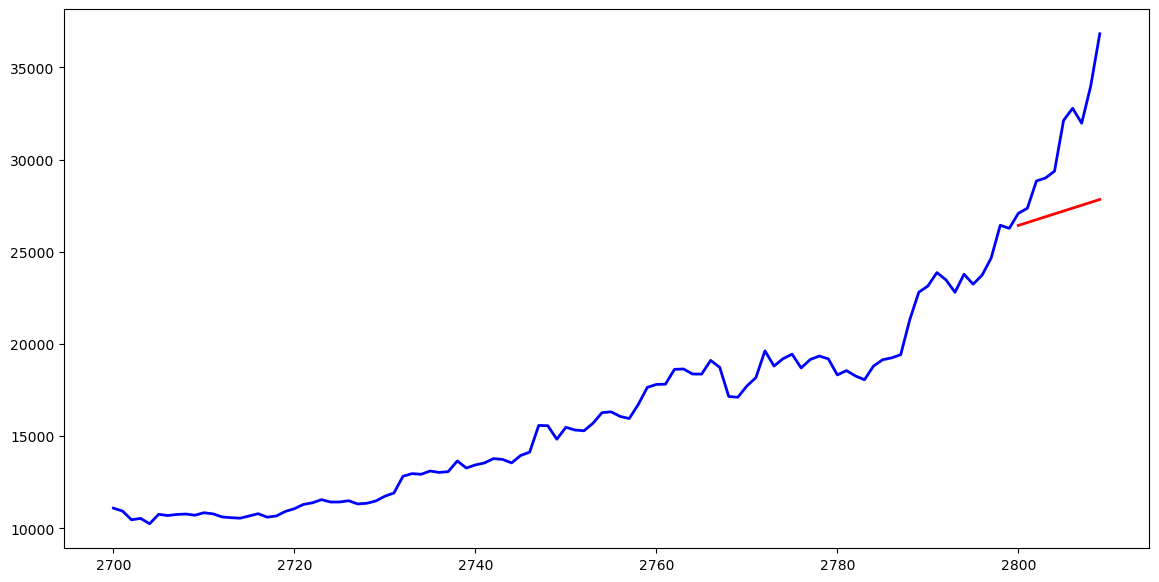

In [13]:
plt.figure(figsize=(14, 7))

plt.plot(btc_test.index, btc_test['Close'], color='blue', linewidth=2)
plt.plot(forecast_dates, forecast, color='red', linewidth=2)

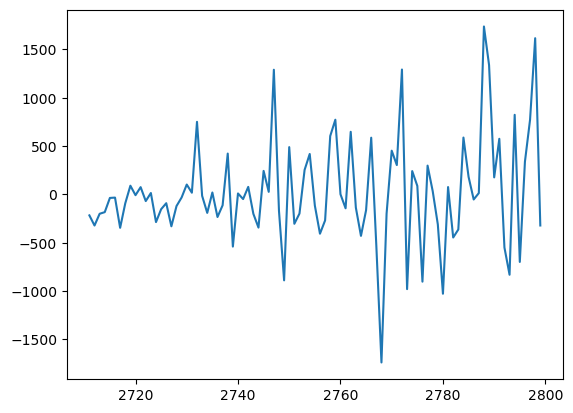

In [14]:
residuals = model.resid().iloc[10:]

plt.plot(residuals)

In [15]:
from scipy import stats

shapiro_test = stats.shapiro(residuals)

print('p-value:', shapiro_test[1])

if shapiro_test[1] > 0.05:
    print("Остатки нормальны")
else:
    print("Остатки не нормальны")

p-value: 0.0005178791470825672
Остатки не нормальны


In [16]:
from pmdarima import auto_arima

model = auto_arima(
    btc_train['Close'],
    d = 4,
    seasonal=False,
    stepwise=False,
    trace=True,
    boxcox=-0.427
)

 ARIMA(0,4,0)(0,0,0)[0]             : AIC=1728.001, Time=0.02 sec
 ARIMA(0,4,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(0,4,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(0,4,3)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(0,4,4)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(0,4,5)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(1,4,0)(0,0,0)[0]             : AIC=1673.748, Time=0.01 sec
 ARIMA(1,4,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,4,2)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(1,4,3)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(1,4,4)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,4,0)(0,0,0)[0]             : AIC=1632.397, Time=0.01 sec
 ARIMA(2,4,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(2,4,2)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(2,4,3)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(3,4,0)(0,0,0)[0]             : AIC=1608.870, Time=0.01 sec
 ARI

In [17]:
forecast, conf_int = model.predict(n_periods=10, return_conf_int=True)

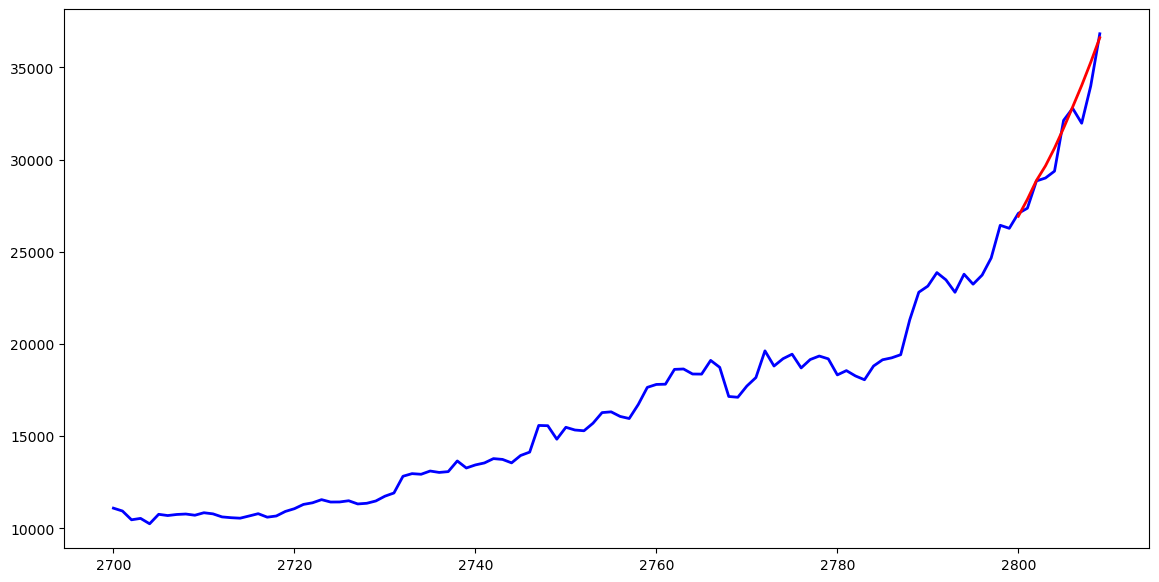

In [18]:
plt.figure(figsize=(14, 7))

plt.plot(btc_test.index, btc_test['Close'], color='blue', linewidth=2)
plt.plot(forecast_dates, forecast, color='red', linewidth=2)

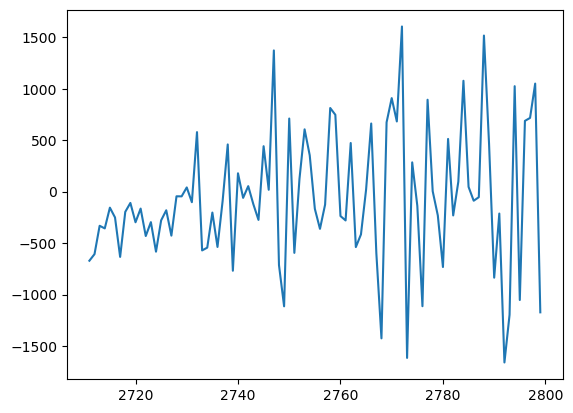

In [19]:
residuals = model.resid().iloc[10:]

plt.plot(residuals)

In [20]:
from scipy import stats

shapiro_test = stats.shapiro(residuals)

print('p-value:', shapiro_test[1])

if shapiro_test[1] > 0.05:
    print("Остатки нормальны")
else:
    print("Остатки не нормальны")

p-value: 0.20158188045024872
Остатки нормальны


In [21]:
t_stat, p_value = stats.ttest_1samp(residuals, popmean=0)

print("p-value:", p_value)

if p_value > 0.05:
    print("Остатки имеют нулевое среднее (модель несмещенная)")
else:
    print("Остатки имеют систематическое смещение (модель смещенная)")

p-value: 0.31179023638180325
Остатки имеют нулевое среднее (модель несмещенная)


In [22]:
result = adfuller(residuals)

print('p-value:', result[1])     

if result[1] <= 0.05:
    print("Ряд стационарен")
else:
    print("Ряд не стационарен")

p-value: 7.839397345738776e-17
Ряд стационарен


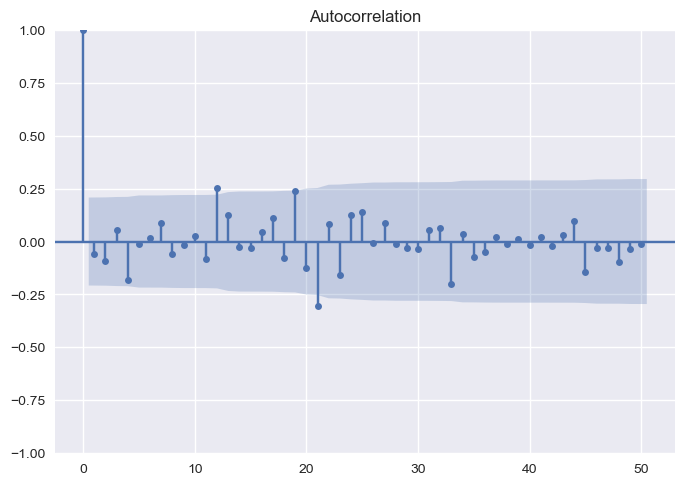

In [63]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=50)
plt.show()


In [64]:
from statsmodels.stats.diagnostic import acorr_ljungbox

test_results = acorr_ljungbox(residuals, lags=[50], return_df=True)  
print(test_results)

      lb_stat  lb_pvalue
50  62.573125   0.109246


In [ ]:
Если pvalue > 0.05 -> автокорреляция отсутствует

Если pvalue <= 0.05 -> есть автокорреляция